# Visualisation des domaines spatiaux

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from shapely.geometry import box

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
})

## Chargement du shapefile

In [2]:
filename = "grands_domaines_cartenat.shp"
candidate_paths = [
    Path.cwd() / "Domains" / filename,
    Path.cwd() / "phdseydi" / "Domains" / filename,
]

shapefile_path = next((path.resolve() for path in candidate_paths if path.exists()), None)
if shapefile_path is None:
    searched = "\n".join(f"  - {path}" for path in candidate_paths)
    raise FileNotFoundError(
        "Shapefile introuvable. Chemins examinés :\n" + searched
    )

required_sidecars = [".shp", ".shx", ".dbf", ".prj"]
missing = [suffix for suffix in required_sidecars if not shapefile_path.with_suffix(suffix).exists()]
if missing:
    raise FileNotFoundError(f"Fichiers associés manquants : {', '.join(missing)}")

print(f"Fichier chargé : {shapefile_path}")
domains = gpd.read_file(shapefile_path, encoding="cp1252")

# Les figures FCat utilisent ce fichier de contours en longitude/latitude
coastline_path = shapefile_path.parent.parent / "use_case" / "coastlines_france.txt"
if not coastline_path.exists():
    raise FileNotFoundError(f"Contours FCat introuvables : {coastline_path}")

coastline_coordinates = np.loadtxt(coastline_path)
separator_rows = np.where(np.any(~np.isfinite(coastline_coordinates), axis=1))[0]
france_boundaries = []
start = 0
for stop in np.append(separator_rows, len(coastline_coordinates)):
    segment = coastline_coordinates[start:stop]
    if len(segment) >= 2:
        france_boundaries.append(segment)
    start = stop + 1

print(f"Contours FCat chargés : {len(france_boundaries)} segments")
domains.head()

Fichier chargé : /Users/ibrahimseydi/Documents/phdseydi/Domains/grands_domaines_cartenat.shp
Contours FCat chargés : 1241 segments


,ID,NAME,ID_DOMAIN,HMIN_KM,HMAX_KM,DELTA_KM,REGION,A,B,DA,...,ARATIO,SOF,ZMIN,ZMAX,ZPEAK,MMAX_PRIOR,MMAX_OBS,MMAX_D_YRS,AREAKM2,geometry
0,1,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,"POLYGON ((3.01919 47.40099, 3.63324 47.6522, 4..."
1,2,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,"POLYGON ((0.33615 43.1739, 1.13574 43.08152, 1..."
2,3,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,"POLYGON ((0.4335 41.25139, 1.02252 41.56152, 1..."
3,4,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,"POLYGON ((0.36237 39.60086, 0.98064 40.27749, ..."
4,5,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,"POLYGON ((14.07875 40.01274, 15.27454 39.27983..."


In [ ]:
domains_wgs84 = domains.to_crs("EPSG:4326").copy()

label_column = None
for column in ["NAME", "ID_DOMAIN", "REGION", "ID"]:
    if column not in domains_wgs84.columns:
        continue
    values = domains_wgs84[column].astype("string").fillna("").str.strip()
    if values.ne("").any():
        label_column = column
        break

if label_column is None:
    domains_wgs84["_label"] = [str(index + 1) for index in range(len(domains_wgs84))]
else:
    raw_labels = domains_wgs84[label_column].astype("string").fillna("").str.strip()
    fallback = domains_wgs84.index.to_series().add(1).astype(str)
    domains_wgs84["_label"] = raw_labels.mask(raw_labels.eq(""), fallback)

# Un indice numérique donne une couleur stable et distincte à chaque polygone
domains_wgs84["_color_id"] = range(len(domains_wgs84))
print(f"Champ utilisé pour les étiquettes : {label_column or 'index'}")

Champ utilisé pour les étiquettes : ID


## Carte des domaines

Les numéros inscrits sur la carte correspondent au champ sélectionné ci-dessus. La même palette est utilisée sur les deux vues. Les limites de la France sont superposées à partir du fichier `use_case/coastlines_france.txt`, comme ce qu'on a fait avec les les figures FCat

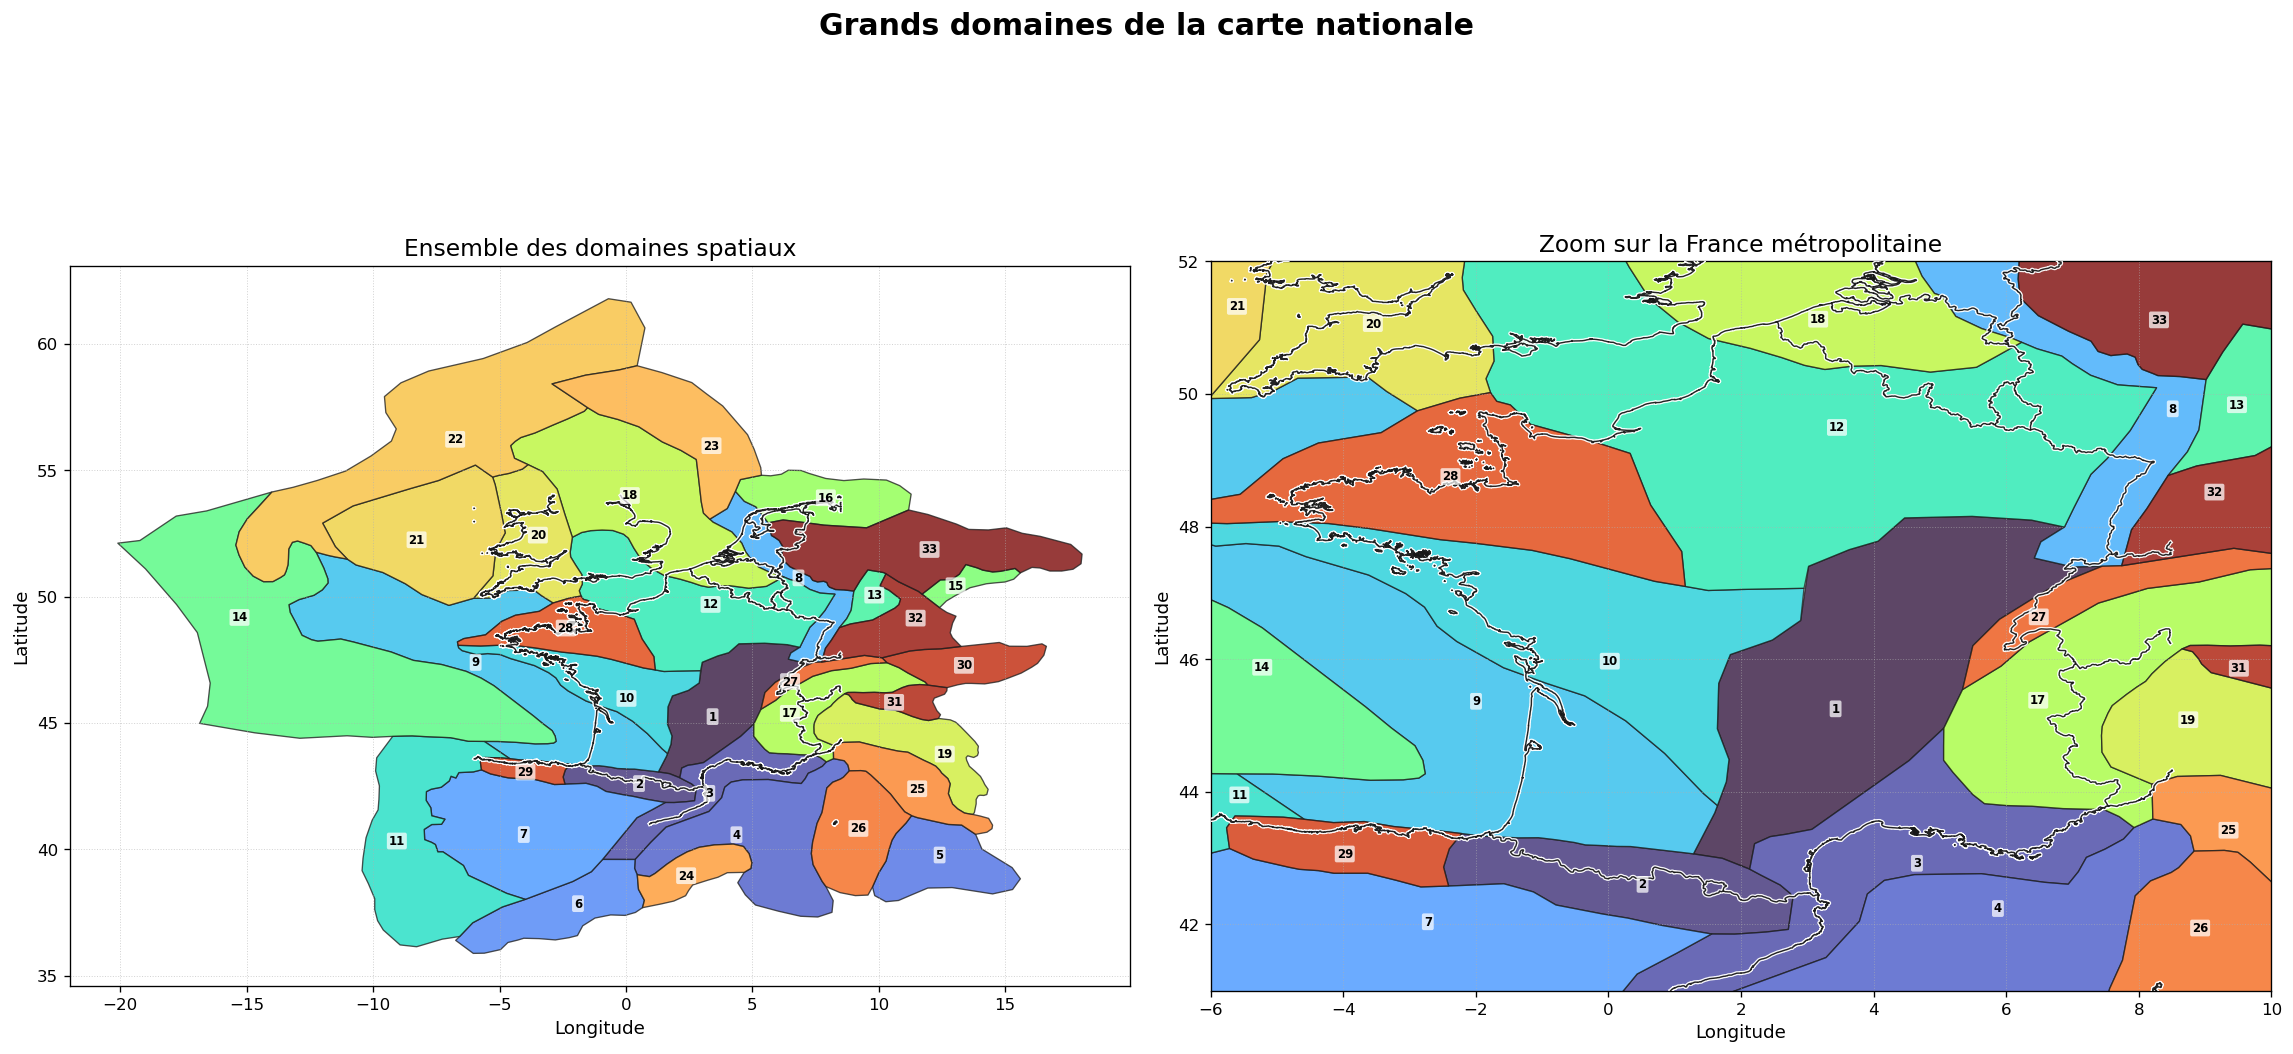

In [4]:
france_bounds = (-6.0, 41.0, 10.0, 52.0)  # ouest, sud, est, nord
cmap = "turbo"
normalization = Normalize(vmin=0, vmax=max(len(domains_wgs84) - 1, 1))

def add_france_boundaries(ax, boundaries):
    # Double tracé : halo clair puis trait sombre, lisible sur toutes les couleurs.
    for segment in boundaries:
        longitude, latitude = segment.T
        ax.plot(longitude, latitude, color="white", linewidth=2.4, alpha=0.95, zorder=5)
        ax.plot(longitude, latitude, color="#181818", linewidth=0.85, alpha=0.95, zorder=6)

def add_domain_labels(ax, data, bounds=None):
    visible = data
    geometries = visible.geometry

    if bounds is not None:
        viewport = box(*bounds)
        visible = data.loc[data.intersects(viewport)].copy()
        geometries = visible.geometry.intersection(viewport)

    points = geometries.representative_point()
    for point, label in zip(points, visible["_label"]):
        if point.is_empty:
            continue
        ax.annotate(
            str(label),
            (point.x, point.y),
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
            color="black",
            zorder=7,
            bbox={"boxstyle": "round,pad=0.16", "facecolor": "white", "alpha": 0.72, "edgecolor": "none"},
        )

fig, axes = plt.subplots(1, 2, figsize=(19, 10), constrained_layout=True)

for ax in axes:
    domains_wgs84.plot(
        ax=ax,
        column="_color_id",
        cmap=cmap,
        norm=normalization,
        edgecolor="#202020",
        linewidth=0.8,
        alpha=0.78,
    )
    add_france_boundaries(ax, france_boundaries)
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.55)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

axes[0].set_title("Ensemble des domaines spatiaux")
add_domain_labels(axes[0], domains_wgs84)

axes[1].set_title("Zoom sur la France métropolitaine")
axes[1].set_xlim(france_bounds[0], france_bounds[2])
axes[1].set_ylim(france_bounds[1], france_bounds[3])
add_domain_labels(axes[1], domains_wgs84, france_bounds)

fig.suptitle("Grands domaines de la carte nationale", fontsize=18, fontweight="bold")
plt.show()

## Localisations spatiales des catalogues

COMCAT (1981–2022, M ≥ 2.0) : 153 401 localisations valides — /Users/ibrahimseydi/Documents/Docs Guillaume - DATA/COMCAT_CI_CATALOG_1981_2022_Mgeq2.0.csv
LDG (1962–2020) : 94 230 localisations valides — /Users/ibrahimseydi/Documents/Docs Guillaume - DATA/LDG1962-2020_eq_4EDF_converted_Mw_20250505_formatted.csv


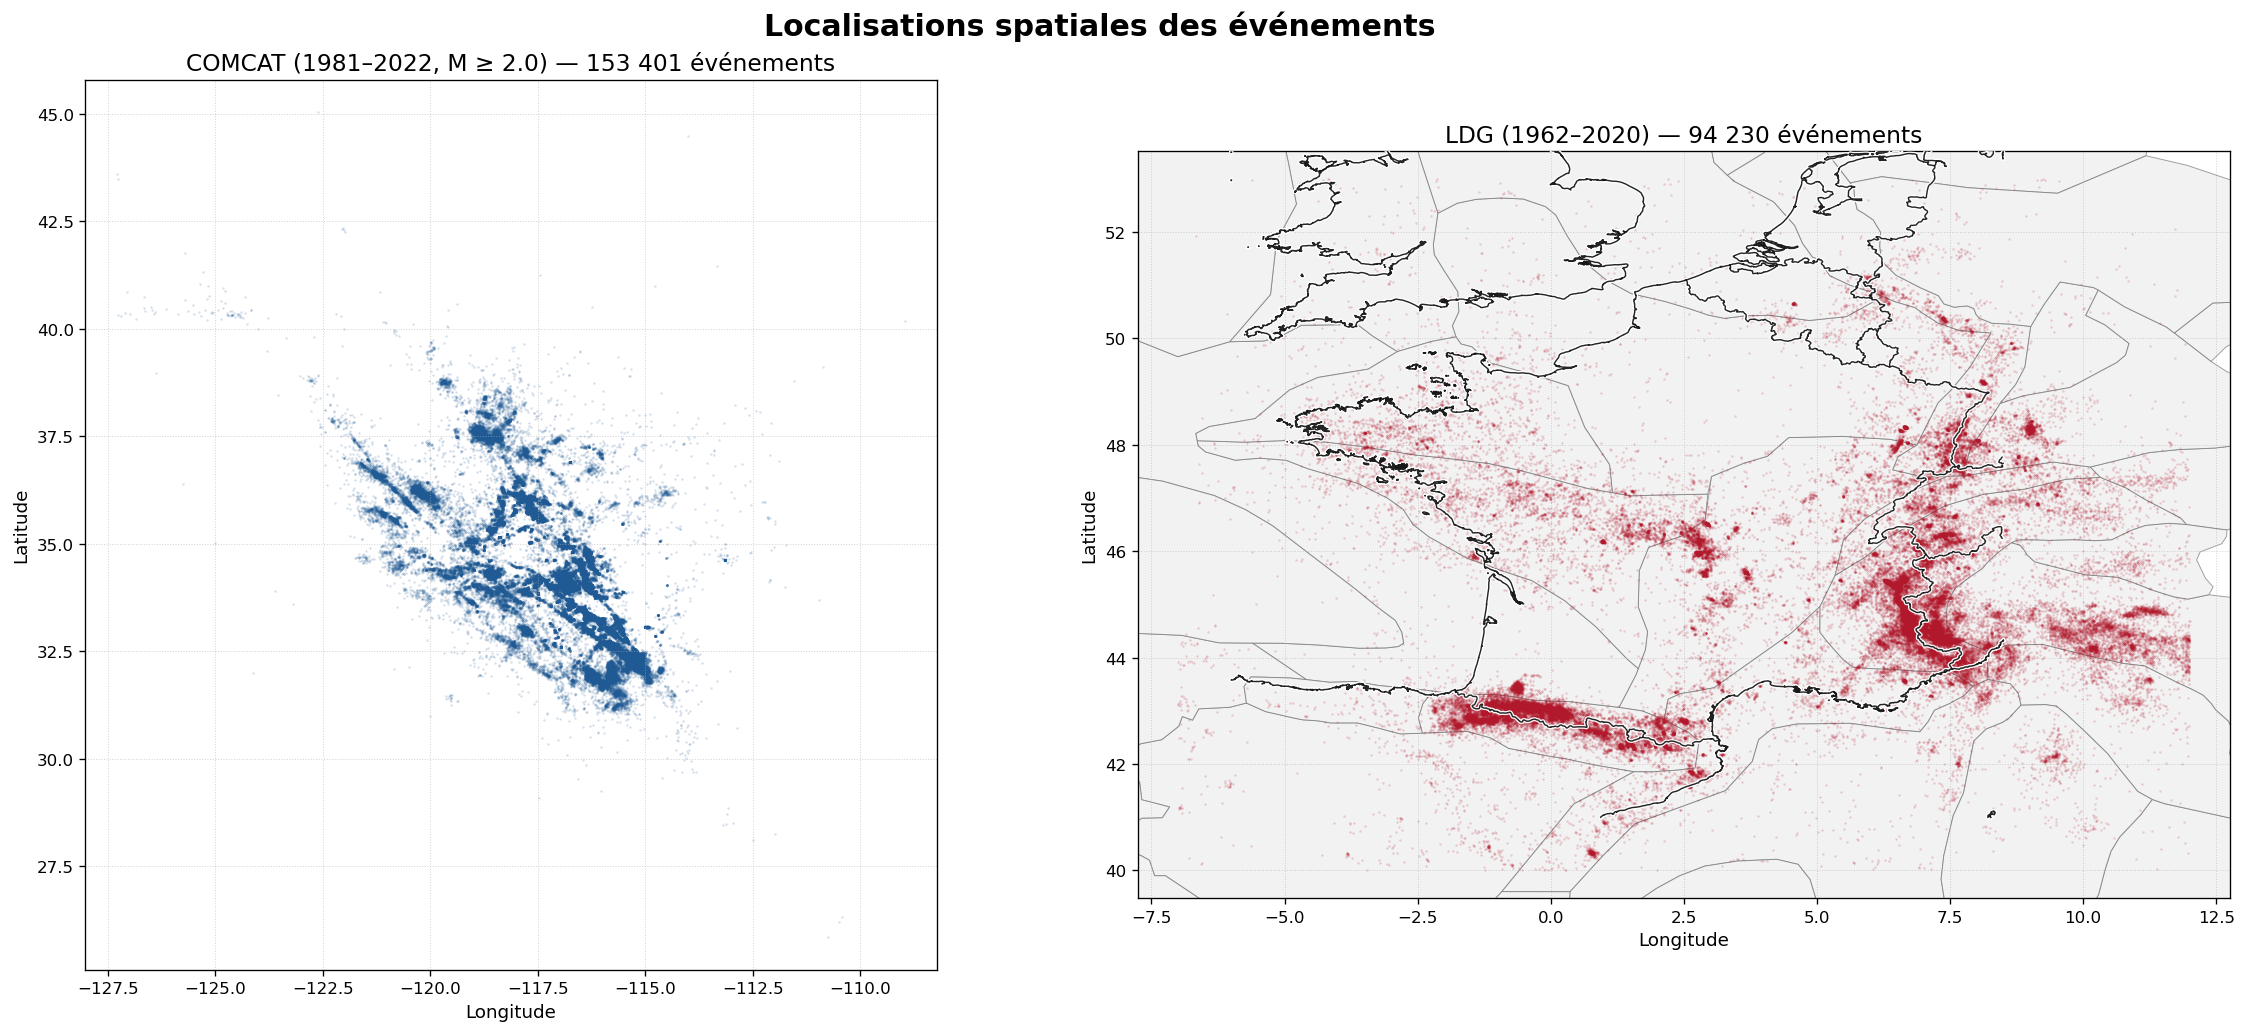

In [5]:
project_root = shapefile_path.parent.parent
documents_root = project_root.parent
catalog_directories = [
    project_root / "Data",
    documents_root / "Docs Guillaume - DATA",
    documents_root / "(old) phdthesisseydi" / "Data",
]

catalog_filenames = {
    "COMCAT (1981–2022, M ≥ 2.0)": "COMCAT_CI_CATALOG_1981_2022_Mgeq2.0.csv",
    "LDG (1962–2020)": "LDG1962-2020_eq_4EDF_converted_Mw_20250505_formatted.csv",
}

def locate_catalog(filename):
    candidates = [directory / filename for directory in catalog_directories]
    path = next((candidate.resolve() for candidate in candidates if candidate.exists()), None)
    if path is None:
        searched = "\n".join(f"  - {candidate}" for candidate in candidates)
        raise FileNotFoundError(f"Catalogue {filename} introuvable. Chemins examinés :\n{searched}")
    return path

def load_catalog_locations(path):
    frame = pd.read_csv(
        path,
        sep=";",
        skipinitialspace=True,
        usecols=lambda column: column.strip() in {"latitude", "longitude"},
    )
    frame.columns = frame.columns.str.strip()
    for column in ["longitude", "latitude"]:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame = frame.dropna(subset=["longitude", "latitude"])
    return frame.loc[
        frame["longitude"].between(-180, 180)
        & frame["latitude"].between(-90, 90)
    ].copy()

catalog_paths = {name: locate_catalog(filename) for name, filename in catalog_filenames.items()}
catalog_locations = {name: load_catalog_locations(path) for name, path in catalog_paths.items()}

def format_count(value):
    return f"{value:,}".replace(",", " ")

for name, frame in catalog_locations.items():
    print(f"{name} : {format_count(len(frame))} localisations valides — {catalog_paths[name]}")

def set_padded_extent(ax, frame, padding_ratio=0.04):
    west, east = frame["longitude"].min(), frame["longitude"].max()
    south, north = frame["latitude"].min(), frame["latitude"].max()
    longitude_padding = max((east - west) * padding_ratio, 0.2)
    latitude_padding = max((north - south) * padding_ratio, 0.2)
    ax.set_xlim(west - longitude_padding, east + longitude_padding)
    ax.set_ylim(south - latitude_padding, north + latitude_padding)

fig, axes = plt.subplots(1, 2, figsize=(19, 8.5), constrained_layout=True)

comcat_name, ldg_name = catalog_filenames
comcat = catalog_locations[comcat_name]
ldg = catalog_locations[ldg_name]

axes[0].scatter(
    comcat["longitude"],
    comcat["latitude"],
    s=2,
    color="#1f5a94",
    alpha=0.20,
    linewidths=0,
    rasterized=True,
)
set_padded_extent(axes[0], comcat)
axes[0].set_title(f"{comcat_name} — {format_count(len(comcat))} événements")

domains_wgs84.plot(
    ax=axes[1],
    facecolor="#eeeeee",
    edgecolor="#777777",
    linewidth=0.55,
    alpha=0.72,
    zorder=1,
)
axes[1].scatter(
    ldg["longitude"],
    ldg["latitude"],
    s=2,
    color="#b2182b",
    alpha=0.20,
    linewidths=0,
    rasterized=True,
    zorder=3,
)
add_france_boundaries(axes[1], france_boundaries)
set_padded_extent(axes[1], ldg)
axes[1].set_title(f"{ldg_name} — {format_count(len(ldg))} événements")

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.55)

fig.suptitle("Localisations spatiales des événements", fontsize=18, fontweight="bold")
plt.show()

## Premier test LDG : 2010–2019 et $M_L \geq 1{,}8$

17 634 événements — du 01/01/2010 au 31/12/2019 — M_L minimal = 1.8


,latitude,longitude,ML,magnitude
event_time,,,,
2010-01-01 02:15:58,44.7323,6.7830,2.04,1.80
2010-01-01 07:56:48,44.0878,8.8224,2.68,2.70
2010-01-01 13:01:37,48.3115,6.6808,1.98,1.74
2010-01-02 04:07:19,46.4902,0.5144,1.89,1.27
2010-01-02 14:21:02,44.3902,6.6409,2.52,2.22


Depuis le 01/01/2017 : 5 439 événements


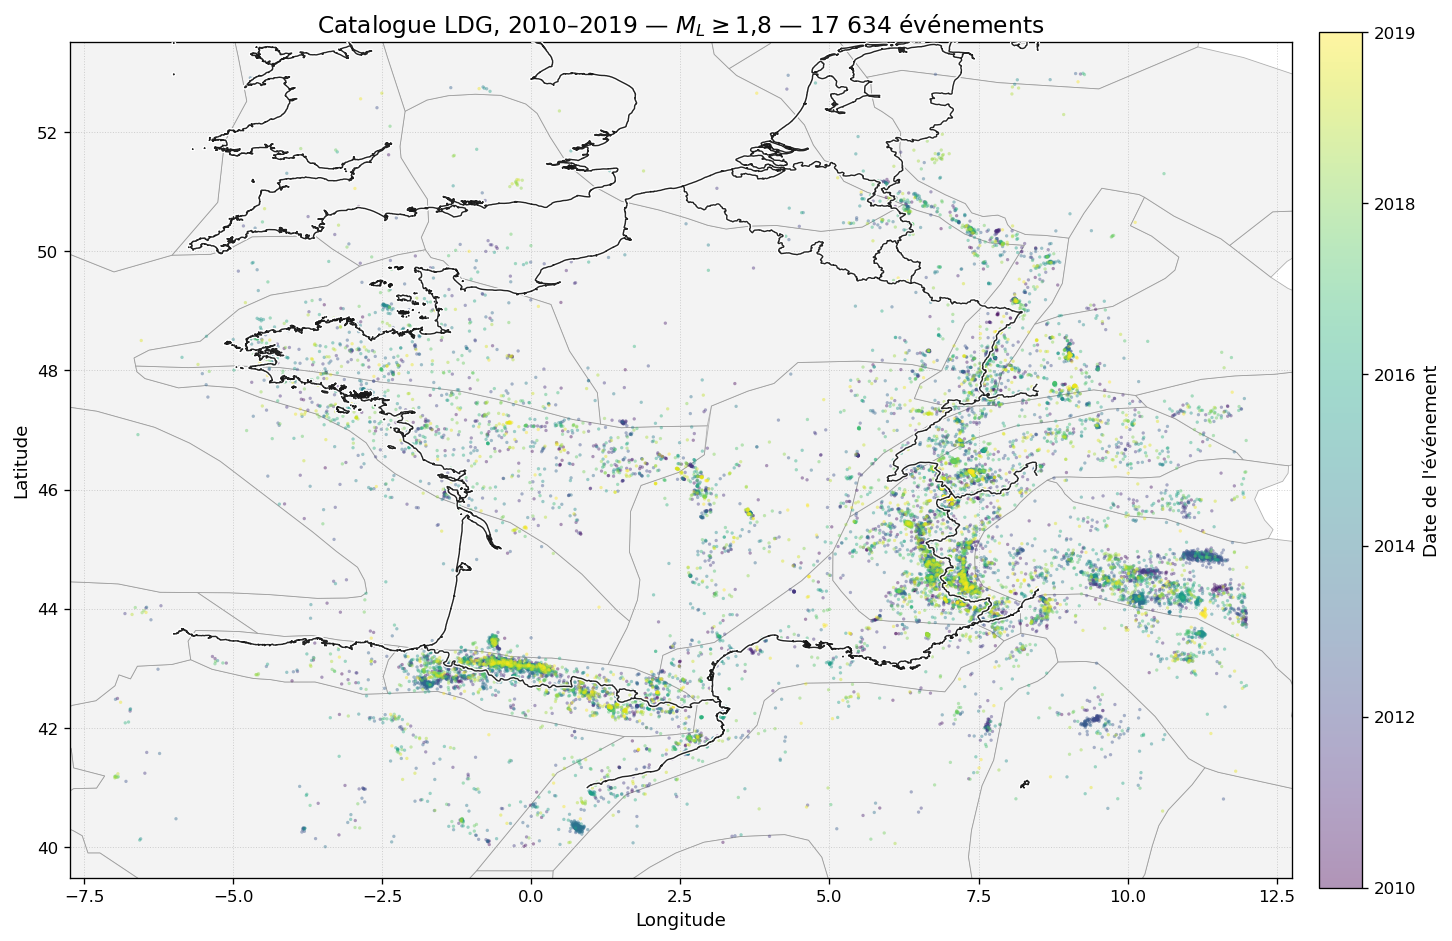

In [6]:
ldg_columns = {"dd-mm-yyyy", "hh-mm-ss", "latitude", "longitude", "ML", "magnitude"}
ldg_events = pd.read_csv(
    catalog_paths[ldg_name],
    sep=";",
    skipinitialspace=True,
    usecols=lambda column: column.strip() in ldg_columns,
)
ldg_events.columns = ldg_events.columns.str.strip()
ldg_events["event_time"] = pd.to_datetime(
    ldg_events["dd-mm-yyyy"].astype("string").str.strip()
    + " "
    + ldg_events["hh-mm-ss"].astype("string").str.strip(),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

for column in ["latitude", "longitude", "ML", "magnitude"]:
    ldg_events[column] = pd.to_numeric(ldg_events[column], errors="coerce")

ldg_events[["ML", "magnitude"]] = ldg_events[["ML", "magnitude"]].replace(-999, np.nan)
ldg_events = (
    ldg_events.dropna(subset=["event_time", "longitude", "latitude", "ML"])
    .loc[lambda frame: frame["longitude"].between(-180, 180) & frame["latitude"].between(-90, 90)]
    .set_index("event_time")
    .sort_index()
)

def get_ldg_events(start_date, end_date=None, min_ml=1.8):
    """Sélectionne le catalogue LDG trié à partir de start_date (end_date exclue)."""
    mask = (ldg_events.index >= pd.Timestamp(start_date)) & (ldg_events["ML"] >= min_ml)
    if end_date is not None:
        mask &= ldg_events.index < pd.Timestamp(end_date)
    return ldg_events.loc[mask].copy()

ldg_2010_2019 = get_ldg_events("2010-01-01", "2020-01-01", min_ml=1.8)
print(
    f"{format_count(len(ldg_2010_2019))} événements — "
    f"du {ldg_2010_2019.index.min():%d/%m/%Y} au {ldg_2010_2019.index.max():%d/%m/%Y} — "
    f"M_L minimal = {ldg_2010_2019['ML'].min():.1f}"
)
display(ldg_2010_2019[["latitude", "longitude", "ML", "magnitude"]].head())

# Exemple : récupérer rapidement tous les événements depuis une date donnée.
events_since_2017 = get_ldg_events("2017-01-01", "2020-01-01", min_ml=1.8)
print(f"Depuis le 01/01/2017 : {format_count(len(events_since_2017))} événements")

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
domains_wgs84.plot(
    ax=ax,
    facecolor="#eeeeee",
    edgecolor="#888888",
    linewidth=0.5,
    alpha=0.65,
    zorder=1,
)
date_numbers = mdates.date2num(ldg_2010_2019.index.to_pydatetime())
points = ax.scatter(
    ldg_2010_2019["longitude"],
    ldg_2010_2019["latitude"],
    c=date_numbers,
    cmap="viridis",
    s=4,
    alpha=0.42,
    linewidths=0,
    rasterized=True,
    zorder=3,
)
add_france_boundaries(ax, france_boundaries)
set_padded_extent(ax, ldg_2010_2019)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.55)
ax.set_title(
    rf"Catalogue LDG, 2010–2019 — $M_L \geq 1{{,}}8$ — {format_count(len(ldg_2010_2019))} événements"
)

tick_years = [2010, 2012, 2014, 2016, 2018, 2019]
tick_dates = pd.DatetimeIndex(
    [pd.Timestamp(f"{year}-01-01") for year in tick_years[:-1]]
    + [pd.Timestamp("2019-12-31 23:59:59")]
)
colorbar = fig.colorbar(points, ax=ax, fraction=0.035, pad=0.02)
colorbar.set_ticks(mdates.date2num(tick_dates.to_pydatetime()))
colorbar.set_ticklabels(tick_years)
colorbar.set_label("Date de l'événement")
plt.show()

## Petit test SPIN-H : MF-VI, GP sparse, sans troncature temporelle

In [ ]:
import sys
import warnings

from shapely.affinity import scale as scale_geometry
from tqdm import TqdmWarning


spin_hawkes_repo = (project_root / "SPIN_Hawkes").resolve()
if not (spin_hawkes_repo / "package").is_dir():
    raise FileNotFoundError(f"Implémentation SPIN_Hawkes introuvable : {spin_hawkes_repo}")
if str(spin_hawkes_repo) not in sys.path:
    sys.path.insert(0, str(spin_hawkes_repo))

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=TqdmWarning)
    import package as spin_hawkes_package
    from package import EventCatalog, ETASParameters, GPParameters, SPINHModel, SPINHVIConfig, SparseGP

spin_hawkes_source = Path(spin_hawkes_package.__file__).resolve()
if spin_hawkes_repo not in spin_hawkes_source.parents:
    raise ImportError(
        f"SPIN-H a été importé depuis {spin_hawkes_source}, et non depuis {spin_hawkes_repo}. "
        "Redémarrer le noyau puis réexécuter le notebook."
    )


pilot_start = pd.Timestamp("2010-01-01")
pilot_end = pd.Timestamp("2010-04-01")  # borne de fin exclue
pilot_events = get_ldg_events(pilot_start, pilot_end, min_ml=1.8)

# SPIN-H requiert des distances projetées : Lambert-93, puis conversion m -> km.
pilot_points_l93 = gpd.GeoDataFrame(
    pilot_events.copy(),
    geometry=gpd.points_from_xy(pilot_events["longitude"], pilot_events["latitude"]),
    crs="EPSG:4326",
).to_crs("EPSG:2154")
pilot_events = pilot_events.assign(
    x_km=pilot_points_l93.geometry.x.to_numpy() / 1_000.0,
    y_km=pilot_points_l93.geometry.y.to_numpy() / 1_000.0,
)

# Les 33 polygones se recouvrent : leur union forme un domaine pilote valide et non recouvrant
observation_geometry_m = domains_wgs84.to_crs("EPSG:2154").geometry.union_all()
observation_geometry_km = scale_geometry(
    observation_geometry_m, xfact=1e-3, yfact=1e-3, origin=(0.0, 0.0)
)
x_min, y_min, x_max, y_max = map(float, observation_geometry_km.bounds)

time_days = (pilot_events.index - pilot_start).total_seconds().to_numpy() / 86_400.0
duration_days = (pilot_end - pilot_start).total_seconds() / 86_400.0
spinh_catalog = EventCatalog(
    t=time_days,
    x=pilot_events["x_km"].to_numpy(),
    y=pilot_events["y_km"].to_numpy(),
    magnitudes=pilot_events["ML"].to_numpy(),
)

# Valeurs initiales exploratoires : temps en jours et distances en kilomètres.
initial_etas = ETASParameters(
    A=0.30,
    alpha=0.50,
    c=0.03,
    p=1.30,
    d=25.0,      # échelle spatiale en km^2 dans le noyau du dépôt SPIN-H ????
    q=1.70,
    gamma=0.20,
)
spinh_model = SPINHModel.from_polygons(
    polygons=[observation_geometry_km],
    duration=duration_days,
    x_bounds=(x_min, x_max),
    y_bounds=(y_min, y_max),
    gp_prior=GPParameters(variance=1.0, length_scale=150.0),
    etas_parameters=initial_etas,
    eps_prior_length_scale=250.0,
    magnitude_min=1.8,
    magnitude_max=float(pilot_events["ML"].max()),
)


spinh_sparse_gp = SparseGP.from_bounds(
    spinh_model.x_bounds,
    spinh_model.y_bounds,
    spinh_model.gp_prior.variance,
    spinh_model.gp_prior.length_scale,
)
spinh_vi_config = SPINHVIConfig(
    n_iter=25,
    gp_backend="sparse",
    sparse_gp=spinh_sparse_gp,
    use_calibration=False,
    quadrature_nx=12,
    quadrature_ny=12,
    spatial_compensator_grid=12,
    etas_update_start=5,
    etas_update_every=5,
    max_optimizer_iter=5,
    gamma_quadrature_nodes=4,
    parent_time_window=None,  # aucune troncature : tous les événements antérieurs sont candidats
    random_seed=2026,
    verbose=True,
)

domain_indices = spinh_model.validate_catalog(spinh_catalog)
dense_parent_pairs = len(spinh_catalog) * (len(spinh_catalog) - 1) // 2
assert spinh_vi_config.gp_backend == "sparse"
assert spinh_vi_config.parent_time_window is None
print(f"SPIN-H chargé depuis : {spin_hawkes_source}")
print(
    f"Pilote prêt : {len(spinh_catalog)} événements, {duration_days:.0f} jours, "
    f"{dense_parent_pairs:,} couples parent-enfant possibles, "
    f"{spinh_sparse_gp.m} fonctions de base sparse."
)

# L'inférence n'est volontairement PAS lancée dans ce notebook.
# vi_result = spinh_model.vi(spinh_catalog, config=spinh_vi_config)